### Model
UNet-like architecture

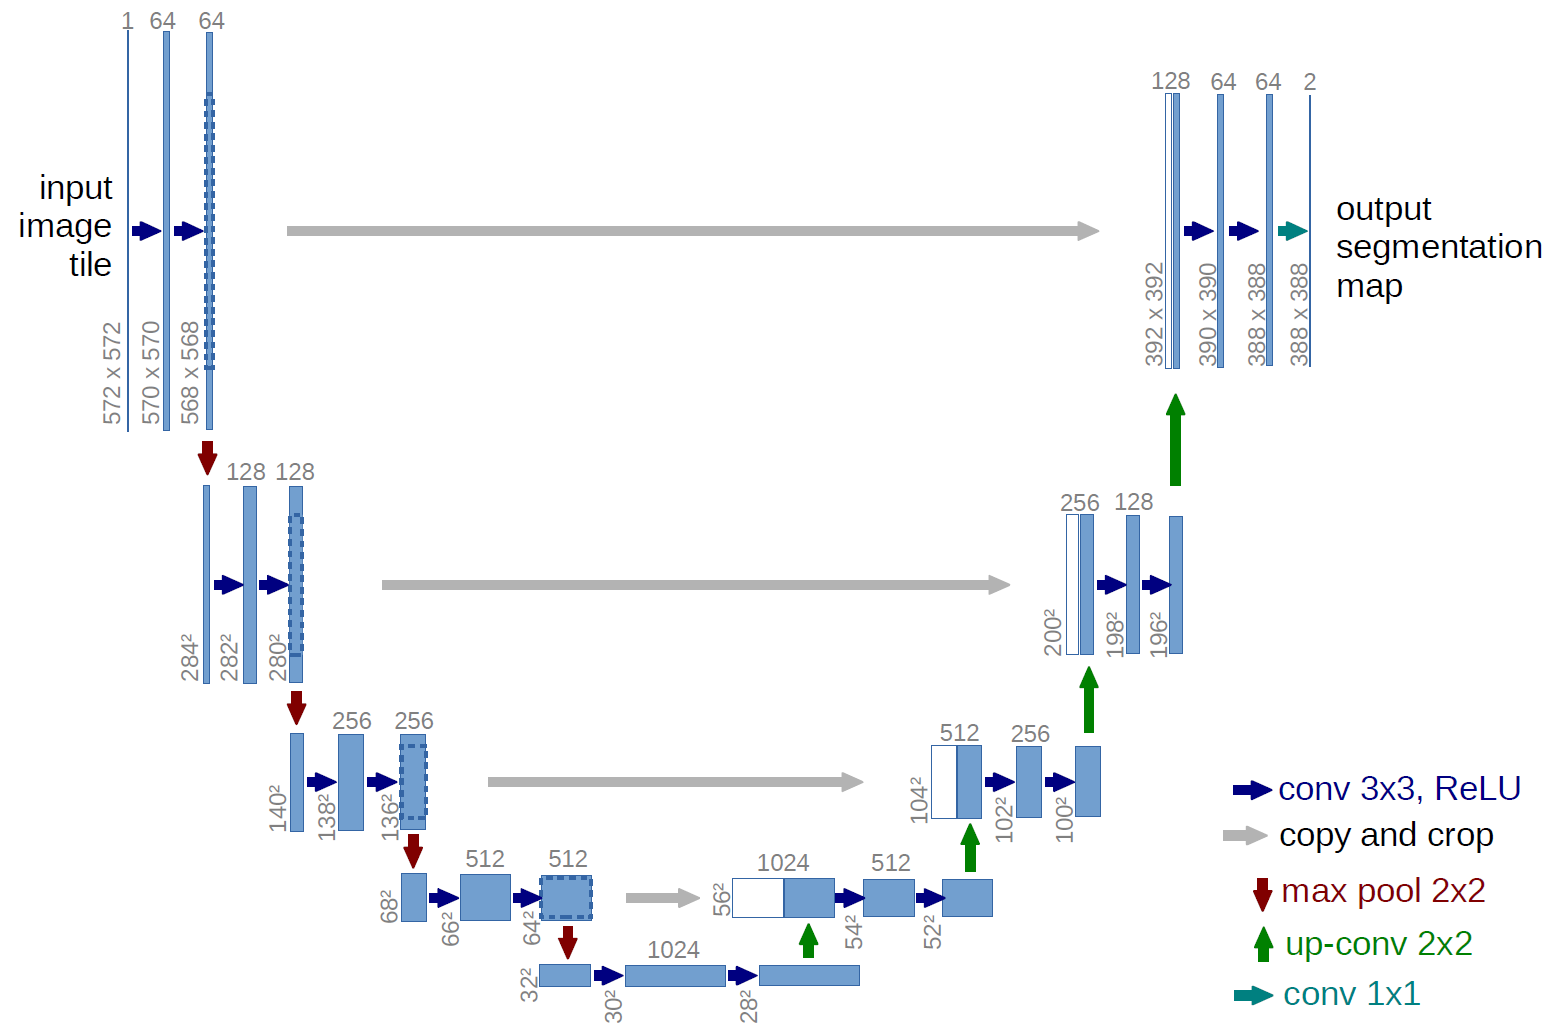

In [1]:
import torch
import torch.nn as nn
import torchvision.transforms.functional as tf

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
    
    def forward(self, x):
        return self.conv(x)
    
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64,128,256,512]):
        super().__init__()
        self.ups = nn.ModuleList()
        self.downs = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Down part of UNet
        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        # Up part of UNet
        for feature in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(feature*2, feature))

        self.bottleneck = DoubleConv(features[-1], features[-1]*2)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx//2]

            if x.shape != skip_connection.shape:
                x = tf.resize(x, size=skip_connection.shape[2:])

            concat_skip = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx+1](concat_skip)

        return self.final_conv(x)

### Train loop

In [2]:
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim
from utils import update_iou_stats

LEARNING_RATE = 1e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16
NUM_EPOCHS = 3
NUM_WORKERS = 4
IMAGE_HEIGHT = 572 # originally: 1500px
IMAGE_WIDTH = 572 # originally: 1500px
PIN_MEMORY = True
LOAD_MODEL = False
TRAIN_IMG_DIR = "data/tiff/train/"
TRAIN_MASK_DIR = "data/tiff/train_labels/"
VAL_IMG_DIR = "data/tiff/val/"
VAL_MASK_DIR = "data/tiff/val_labels/"
TEST_IMG_DIR = "data/tiff/test/"
TEST_MASK_DIR = "data/tiff/test_labels/"

def train_one_epoch(model, loader, optimizer, loss_fn, scaler):
    model.train()

    total_loss = 0.0
    total_samples = 0

    total_intersection = 0.0
    total_union = 0.0

    loop = tqdm(loader)
    for batch_idx, (data, targets) in enumerate(loop):
        data = data.to(device=DEVICE)
        targets = targets.unsqueeze(1).to(device=DEVICE)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            logits = model(data)
            loss = loss_fn(logits, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size = targets.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

        intersection, union = update_iou_stats(logits, targets)
        total_intersection += intersection
        total_union += union

        # update tqdm loop
        loop.set_postfix(loss=loss.item())

    total_loss = total_loss / total_samples
    total_iou = total_intersection / (total_union + 1e-7)

    return total_loss, total_iou


@torch.no_grad()
def evaluate(model, loader, loss_fn):
    model.eval()
    
    total_loss = 0.0
    total_samples = 0

    total_intersection = 0.0
    total_union = 0.0

    for data, targets in loader:
        data = data.to(device=DEVICE)
        targets = targets.unsqueeze(1).to(device=DEVICE)

        logits = model(data)
        loss = loss_fn(logits, targets)

        batch_size = data.size(0)
        total_loss += loss * batch_size
        total_samples += batch_size

        intersection, union = update_iou_stats(logits, targets)

        total_intersection += intersection
        total_union += union

    total_loss = total_loss / total_samples
    total_iou = total_intersection / (total_union + 1e-7)

    return total_loss, total_iou


train_transforms = A.Compose(
    [
        A.Resize(height=IMAGE_HEIGHT, width=IMAGE_WIDTH),
        A.Rotate(limit=35, p=1.0),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.1),
        A.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225),
        ),
        ToTensorV2(),
    ]
)

val_transforms = A.Compose(
    [
        A.Resize(height=IMAGE_HEIGHT, width=IMAGE_WIDTH),
        A.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225),
        ),
        ToTensorV2(),
    ]
)


In [ ]:
from utils import get_loaders

model = UNet(in_channels=3, out_channels=1).to(DEVICE)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_loader, val_loader, test_loader = get_loaders(
    TRAIN_IMG_DIR, TRAIN_MASK_DIR,
    VAL_IMG_DIR, VAL_MASK_DIR,
    TEST_IMG_DIR, TEST_MASK_DIR,
    BATCH_SIZE,
    train_transforms,
    val_transforms,
    NUM_WORKERS,
    PIN_MEMORY
)

scaler = torch.amp.GradScaler("cuda")


history = {
    "train_loss": [],
    "val_loss": [],
    "train_iou": [],
    "val_iou": [],
}
best_val_iou = 0.0

for epoch in range(NUM_EPOCHS):
    train_loss, train_iou = train_one_epoch(model, train_loader, optimizer, loss_fn, scaler)
    val_loss, val_iou = evaluate(model, val_loader, loss_fn)

    history["train_loss"].append(train_loss)
    history["train_iou"].append(train_iou)
    history["val_loss"].append(val_loss)
    history["val_iou"].append(val_iou)

    if val_iou > best_val_iou:
        pass # add checkpoint

    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} | train_acc={train_iou:.4f} | "
        f"val_loss={val_loss:.4f} | val_acc={val_iou:.4f}"
    )
    

  1%|▏         | 1/70 [00:36<42:30, 36.96s/it, loss=0.867]